# Deep Learning for Time Series — LSST + Moirai
**Setting 1 : Adapter un modèle de fondation (Moirai) pour la classification**

Stratégie :
- Encodeur Moirai **gelé** (frozen)
- Seule la **tête de classification** est entraînée
- Compatible **CPU / MacBook** avec Moirai-Small
- Pour les runs finaux → Colab GPU + Moirai-Base/Large

## 0. Installation des dépendances

In [22]:
# À exécuter une seule fois
# Sur Colab : décommentez tout
# Sur MacBook : idem

!pip install tslearn
!pip install uni2ts          # package officiel Salesforce pour Moirai
!pip install matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 1. Chargement du dataset LSST

In [23]:
import numpy as np
import tslearn
from tslearn.datasets import UCR_UEA_datasets

# ⚠️ Doit être fait AVANT d'instancier UCR_UEA_datasets
# Et pointer vers le PARENT de LSST, pas LSST lui-même
tslearn.datasets.UCR_UEA_datasets.DATA_HOME = "/Users/noeamar/Documents/M2DS/Deep Learning for Time Series/Projet"

ds = UCR_UEA_datasets(use_cache=True)
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")
print(f"\nClasses uniques : {np.unique(y_train)}")
print(f"Nombre de classes : {len(np.unique(y_train))}")


X_train : (2459, 36, 6)
X_test  : (2466, 36, 6)
y_train : (2459,)
y_test  : (2466,)

Classes uniques : ['15' '16' '42' '52' '53' '6' '62' '64' '65' '67' '88' '90' '92' '95']
Nombre de classes : 14


## 2. Exploration visuelle

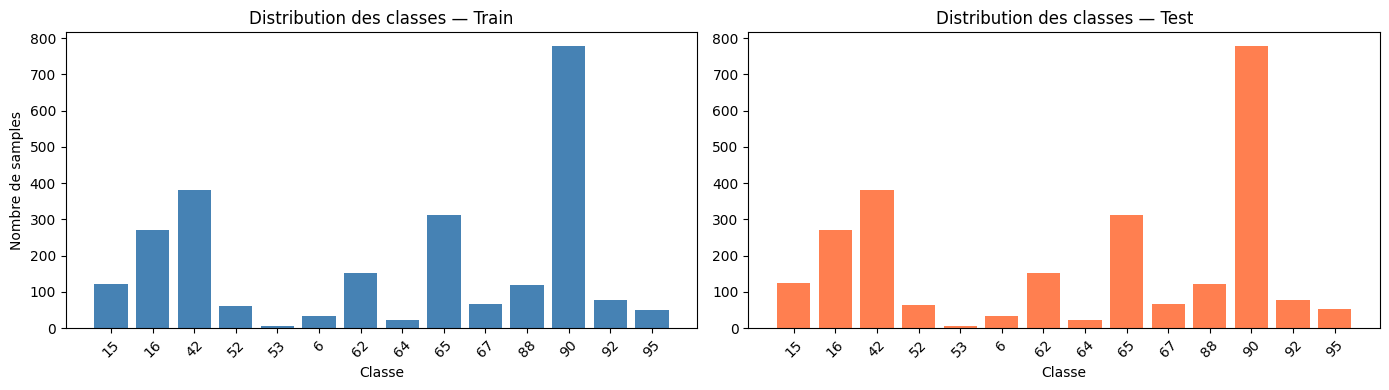

Déséquilibre train : min=7, max=777


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

classes = np.unique(y_train)
n_classes = len(classes)
n_channels = X_train.shape[2]

# --- Distribution des classes ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)

axes[0].bar(unique_train.astype(str), counts_train, color='steelblue')
axes[0].set_title('Distribution des classes — Train')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nombre de samples')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(unique_test.astype(str), counts_test, color='coral')
axes[1].set_title('Distribution des classes — Test')
axes[1].set_xlabel('Classe')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
print(f"Déséquilibre train : min={counts_train.min()}, max={counts_train.max()}")

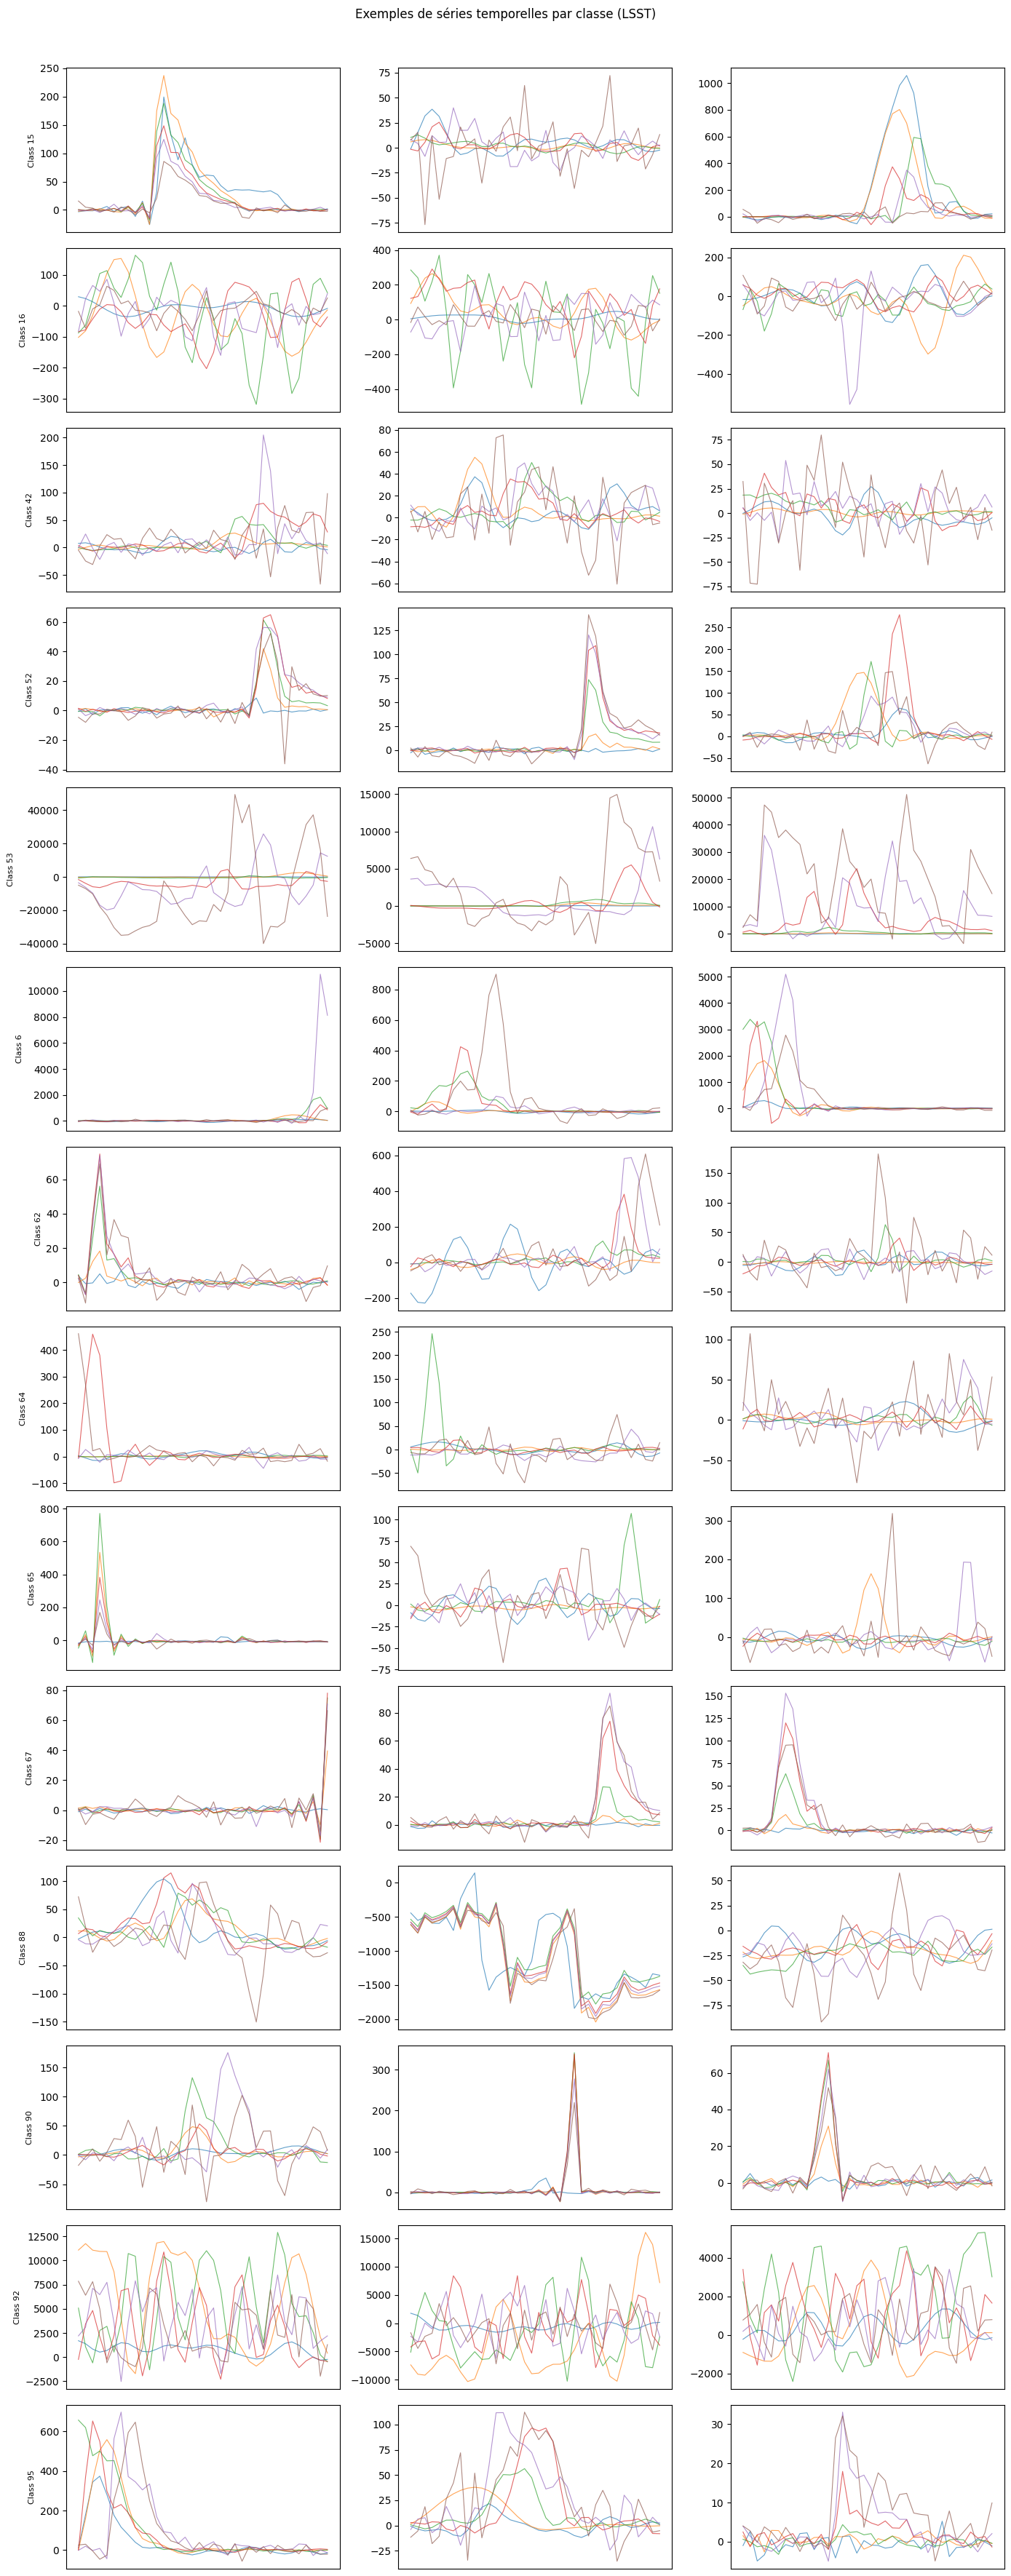

In [25]:
# --- Visualisation de quelques séries par classe ---
n_examples = 3
fig, axes = plt.subplots(n_classes, n_examples, figsize=(14, n_classes * 2.5), sharex=True)

for i, cls in enumerate(classes):
    idx = np.where(y_train == cls)[0][:n_examples]
    for j, sample_idx in enumerate(idx):
        ax = axes[i, j]
        for c in range(n_channels):
            ax.plot(X_train[sample_idx, :, c], alpha=0.7, linewidth=0.8)
        if j == 0:
            ax.set_ylabel(f'Class {cls}', fontsize=8)
        ax.set_xticks([])

plt.suptitle('Exemples de séries temporelles par classe (LSST)', y=1.01)
plt.tight_layout()
plt.show()

In [26]:
# --- Statistiques rapides ---
print("=== Statistiques générales ===")
print(f"Longueur des séries  : {X_train.shape[1]} pas de temps")
print(f"Nombre de canaux     : {X_train.shape[2]}")
print(f"Samples train        : {X_train.shape[0]}")
print(f"Samples test         : {X_test.shape[0]}")
print(f"NaN dans X_train     : {np.isnan(X_train).sum()}")
print(f"NaN dans X_test      : {np.isnan(X_test).sum()}")
print(f"\nValeurs min/max train: {X_train.min():.3f} / {X_train.max():.3f}")

=== Statistiques générales ===
Longueur des séries  : 36 pas de temps
Nombre de canaux     : 6
Samples train        : 2459
Samples test         : 2466
NaN dans X_train     : 0
NaN dans X_test      : 0

Valeurs min/max train: -40036.000 / 64062.000


## 3. Préparation des données — Feature Engineering

Au lieu de passer les séries brutes dans Moirai, on **enrichit chaque canal** avec des features complémentaires avant encodage, et on applique un **prétraitement adapté à l'astronomie LSST** :

1. **Imputation intelligente** : interpolation linéaire sur les NaN (plus réaliste que remplir par 0)
2. **Normalisation per-sample** (z-score par série individuelle) plutôt que globale — chaque étoile a sa propre échelle de magnitude
3. **Features statistiques** extraites sur les embeddings : mean, std, min, max, skewness, kurtosis, autocorrélation lag-1 par canal → concaténées aux embeddings Moirai
4. **Synthetic minority oversampling** sur le train set (SMOTE) pour corriger le déséquilibre de classes


In [27]:
import numpy as np
import torch
from sklearn.preprocessing import LabelEncoder
from scipy import stats as scipy_stats

# ════════════════════════════════════════════════════════════
# 1. Encodage des labels
# ════════════════════════════════════════════════════════════
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
NUM_CLASSES = len(le.classes_)
print(f"Classes : {NUM_CLASSES}  |  Distribution train : {dict(zip(*np.unique(y_train_enc, return_counts=True)))}")

# ════════════════════════════════════════════════════════════
# 2. Imputation : interpolation linéaire par série + canal
#    (bien mieux que nan→0 qui crée de faux zéros bruités)
# ════════════════════════════════════════════════════════════
def interpolate_series(X):
    """X : (N, T, C) → impute NaN par interpolation linéaire par (n, c)."""
    X = X.copy().astype(np.float32)
    N, T, C = X.shape
    t = np.arange(T)
    for n in range(N):
        for c in range(C):
            y = X[n, :, c]
            nans = np.isnan(y)
            if nans.any() and (~nans).sum() >= 2:
                X[n, :, c] = np.interp(t, t[~nans], y[~nans])
            elif nans.all():
                X[n, :, c] = 0.0
    return X

print("Imputation NaN (interpolation linéaire)...")
X_train_imp = interpolate_series(X_train)
X_test_imp  = interpolate_series(X_test)
print(f"NaN résiduels train: {np.isnan(X_train_imp).sum()}  test: {np.isnan(X_test_imp).sum()}")

# ════════════════════════════════════════════════════════════
# 3. Normalisation per-sample z-score par canal
#    Chaque série individuelle est centrée-réduite sur elle-même.
#    → invariance à la magnitude absolue (utile en astro)
# ════════════════════════════════════════════════════════════
def per_sample_zscore(X, eps=1e-6):
    """X : (N, T, C) → normalise chaque (n, c) indépendamment."""
    mu  = X.mean(axis=1, keepdims=True)          # (N, 1, C)
    sig = X.std(axis=1, keepdims=True) + eps
    return (X - mu) / sig

X_train_norm = per_sample_zscore(X_train_imp)
X_test_norm  = per_sample_zscore(X_test_imp)
print(f"Normalisation per-sample OK | min={X_train_norm.min():.2f} max={X_train_norm.max():.2f}")

# ════════════════════════════════════════════════════════════
# 4. Feature engineering statistique par canal
#    Ces features capturent ce que Moirai ne voit pas bien :
#    forme globale, asymétrie, périodicité
# ════════════════════════════════════════════════════════════
def extract_stat_features(X):
    """
    X : (N, T, C) → (N, n_features)
    Par canal : mean, std, min, max, skewness, kurtosis,
                autocorr lag-1, median, IQR, peak-to-peak,
                fraction de valeurs > mean (duty cycle)
    """
    N, T, C = X.shape
    feats = []
    for n in range(N):
        row = []
        for c in range(C):
            s = X[n, :, c]
            mu   = s.mean()
            sig  = s.std() + 1e-6
            row += [
                mu,                                          # mean
                sig,                                         # std
                s.min(),                                     # min
                s.max(),                                     # max
                float(scipy_stats.skew(s)),                  # skewness
                float(scipy_stats.kurtosis(s)),              # kurtosis
                float(np.corrcoef(s[:-1], s[1:])[0, 1]),    # autocorr lag-1
                float(np.median(s)),                         # median
                float(np.percentile(s, 75) - np.percentile(s, 25)),  # IQR
                float(s.max() - s.min()),                    # peak-to-peak
                float((s > mu).mean()),                      # duty cycle
            ]
        feats.append(row)
    return np.array(feats, dtype=np.float32)  # (N, C * 11)

print("Extraction features statistiques...")
stat_train = extract_stat_features(X_train_norm)
stat_test  = extract_stat_features(X_test_norm)

# Normalisation globale des features stat (robuste aux outliers)
from sklearn.preprocessing import RobustScaler
scaler_stat = RobustScaler()
stat_train  = scaler_stat.fit_transform(stat_train)
stat_test   = scaler_stat.transform(stat_test)

STAT_DIM = stat_train.shape[1]
print(f"Features stat : {STAT_DIM} dimensions  (shape: {stat_train.shape})")

# ════════════════════════════════════════════════════════════
# 5. SMOTE sur le train set pour équilibrer les classes
# ════════════════════════════════════════════════════════════
try:
    from imblearn.over_sampling import SMOTE
    # On applique SMOTE sur les features stat (proxy compact des séries)
    # Les séries correspondantes sont reconstruites par association d'index
    smote = SMOTE(random_state=42, k_neighbors=3)
    # Flatten les séries pour SMOTE
    X_flat = X_train_norm.reshape(len(X_train_norm), -1)
    X_flat_resampled, y_resampled = smote.fit_resample(X_flat, y_train_enc)
    X_train_norm_sm = X_flat_resampled.reshape(-1, X_train_norm.shape[1], X_train_norm.shape[2])
    # Recalculer les features stat sur le set augmenté
    stat_train_sm = extract_stat_features(X_train_norm_sm)
    stat_train_sm = scaler_stat.transform(stat_train_sm)
    y_train_sm = y_resampled
    print(f"SMOTE OK : {len(y_train_enc)} → {len(y_train_sm)} samples")
    print(f"Distribution après SMOTE : {dict(zip(*np.unique(y_train_sm, return_counts=True)))}")
    USE_SMOTE = True
except ImportError:
    print("⚠️  imbalanced-learn non installé — pip install imbalanced-learn")
    print("   Continuera sans SMOTE (on utilisera class_weight à la place)")
    X_train_norm_sm = X_train_norm
    stat_train_sm   = stat_train
    y_train_sm      = y_train_enc
    USE_SMOTE = False


Classes : 14  |  Distribution train : {0: 123, 1: 270, 2: 381, 3: 62, 4: 7, 5: 34, 6: 153, 7: 23, 8: 313, 9: 68, 10: 120, 11: 777, 12: 77, 13: 51}
Imputation NaN (interpolation linéaire)...
NaN résiduels train: 0  test: 0
Normalisation per-sample OK | min=-5.85 max=5.91
Extraction features statistiques...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]


Features stat : 66 dimensions  (shape: (2459, 66))
SMOTE OK : 2459 → 10878 samples
Distribution après SMOTE : {0: 777, 1: 777, 2: 777, 3: 777, 4: 777, 5: 777, 6: 777, 7: 777, 8: 777, 9: 777, 10: 777, 11: 777, 12: 777, 13: 777}


## 4. Chargement de Moirai (encodeur gelé)

On utilise **Moirai-Small** pour la compatibilité CPU.  
Sur Colab GPU, remplacez `moirai-1.0-R-small` par `moirai-1.0-R-base` ou `moirai-1.0-R-large`.

In [28]:
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule
import torch
import torch.nn as nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {DEVICE}")

# Charger Moirai depuis HuggingFace Hub
# Modèles disponibles : moirai-1.0-R-small | moirai-1.0-R-base | moirai-1.0-R-large
MODEL_SIZE = "small"   # ← changer en 'base' sur Colab GPU

moirai_module = MoiraiModule.from_pretrained(
    f"Salesforce/moirai-1.0-R-{MODEL_SIZE}"
)
moirai_module = moirai_module.to(DEVICE)

# Geler tous les paramètres de l'encodeur
for param in moirai_module.parameters():
    param.requires_grad = False

moirai_module.eval()
total_params = sum(p.numel() for p in moirai_module.parameters())
print(f"Moirai-{MODEL_SIZE} chargé — {total_params:,} paramètres (tous gelés)")

Device utilisé : cpu
Moirai-small chargé — 13,827,528 paramètres (tous gelés)


## 5. Extraction des embeddings + fusion avec features stat

On concatène les embeddings Moirai avec les features statistiques :  
`embedding_final = [moirai_embedding | stat_features]`  
→ Moirai apporte la structure temporelle, les stats apportent la forme globale.


In [29]:
import math

def patchify_fixed(x, patch_size=128):
    B, T = x.shape
    if patch_size - T > 0:
        x = torch.nn.functional.pad(x, (0, patch_size - T), value=0.0)
    return x.unsqueeze(1)

def extract_embeddings(X_norm, moirai_module, device, batch_size=32, patch_size=128):
    """X_norm : (N, T, C) → (N, D_model * C)"""
    N, T, C = X_norm.shape
    all_embeddings = []
    captured = {}

    def hook_fn(module, input, output):
        captured['enc_out'] = output.detach()

    hook = moirai_module.encoder.register_forward_hook(hook_fn)
    moirai_module.eval()

    with torch.no_grad():
        for start in range(0, N, batch_size):
            batch = X_norm[start:start + batch_size]
            B = batch.shape[0]
            chan_embeddings = []
            for c in range(C):
                x_c     = torch.tensor(batch[:, :, c], dtype=torch.float32)
                patches = patchify_fixed(x_c, patch_size).to(device)
                obs        = torch.zeros(B, 1, patch_size, dtype=torch.bool, device=device)
                obs[:, 0, :T] = True
                sample_id  = torch.zeros(B, 1, dtype=torch.long, device=device)
                time_id    = torch.zeros(B, 1, dtype=torch.long, device=device)
                variate_id = torch.zeros(B, 1, dtype=torch.long, device=device)
                pred_mask  = torch.zeros(B, 1, dtype=torch.bool, device=device)
                ps_tensor  = torch.full((B, 1), patch_size, dtype=torch.long, device=device)
                moirai_module(
                    target=patches, observed_mask=obs,
                    sample_id=sample_id, time_id=time_id,
                    variate_id=variate_id, prediction_mask=pred_mask,
                    patch_size=ps_tensor,
                )
                if 'enc_out' in captured:
                    chan_embeddings.append(captured.pop('enc_out').squeeze(1).cpu())
            if chan_embeddings:
                all_embeddings.append(torch.cat(chan_embeddings, dim=-1))
            if (start // batch_size) % 5 == 0:
                print(f"  Batch {start//batch_size + 1}/{math.ceil(N/batch_size)}")

    hook.remove()
    return torch.cat(all_embeddings, dim=0)

# ── Extraction Moirai ──
print("Extraction embeddings Moirai — Train (avec SMOTE)...")
train_emb_moirai = extract_embeddings(X_train_norm_sm, moirai_module, DEVICE)
print(f"✅ {train_emb_moirai.shape}")

print("\nExtraction embeddings Moirai — Test...")
test_emb_moirai = extract_embeddings(X_test_norm, moirai_module, DEVICE)
print(f"✅ {test_emb_moirai.shape}")

# ── Fusion : [Moirai embedding | stat features] ──
stat_train_t = torch.tensor(stat_train_sm, dtype=torch.float32)
stat_test_t  = torch.tensor(stat_test,     dtype=torch.float32)

train_embeddings = torch.cat([train_emb_moirai, stat_train_t], dim=-1)
test_embeddings  = torch.cat([test_emb_moirai,  stat_test_t],  dim=-1)

EMBED_DIM = train_embeddings.shape[1]
MOIRAI_DIM = train_emb_moirai.shape[1]
print(f"\n✅ Embeddings fusionnés : {train_embeddings.shape}")
print(f"   Moirai : {MOIRAI_DIM}  |  Stat : {STAT_DIM}  |  Total : {EMBED_DIM}")


Extraction embeddings Moirai — Train (avec SMOTE)...
  Batch 1/340
  Batch 6/340
  Batch 11/340
  Batch 16/340
  Batch 21/340
  Batch 26/340
  Batch 31/340
  Batch 36/340
  Batch 41/340
  Batch 46/340
  Batch 51/340
  Batch 56/340
  Batch 61/340
  Batch 66/340
  Batch 71/340
  Batch 76/340
  Batch 81/340
  Batch 86/340
  Batch 91/340
  Batch 96/340
  Batch 101/340
  Batch 106/340
  Batch 111/340
  Batch 116/340
  Batch 121/340
  Batch 126/340
  Batch 131/340
  Batch 136/340
  Batch 141/340
  Batch 146/340
  Batch 151/340
  Batch 156/340
  Batch 161/340
  Batch 166/340
  Batch 171/340
  Batch 176/340
  Batch 181/340
  Batch 186/340
  Batch 191/340
  Batch 196/340
  Batch 201/340
  Batch 206/340
  Batch 211/340
  Batch 216/340
  Batch 221/340
  Batch 226/340
  Batch 231/340
  Batch 236/340
  Batch 241/340
  Batch 246/340
  Batch 251/340
  Batch 256/340
  Batch 261/340
  Batch 266/340
  Batch 271/340
  Batch 276/340
  Batch 281/340
  Batch 286/340
  Batch 291/340
  Batch 296/340
  Batch 3

## 6. Tête de classification (MLP)

Seule cette partie est **entraînée**. L'encodeur Moirai reste gelé.

In [30]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report

EMBED_DIM = train_embeddings.shape[1]

class ClassificationHead(nn.Module):
    def __init__(self, embed_dim, num_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


head = ClassificationHead(EMBED_DIM, NUM_CLASSES).to(DEVICE)
trainable = sum(p.numel() for p in head.parameters() if p.requires_grad)
print(f"Tête de classification : {trainable:,} paramètres entraînables")

Tête de classification : 646,418 paramètres entraînables


## 7. Entraînement

In [31]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score

# ── Class weights si pas de SMOTE ──
if not USE_SMOTE:
    counts = np.bincount(y_train_sm)
    cw = torch.tensor(1.0 / counts, dtype=torch.float32).to(DEVICE)
    cw = cw / cw.sum() * NUM_CLASSES
    criterion = nn.CrossEntropyLoss(weight=cw, label_smoothing=0.1)
    print("Cross-entropy avec class weights (pas de SMOTE)")
else:
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    print("Cross-entropy avec label smoothing")

EPOCHS       = 1000
BATCH_SIZE   = 64
LR           = 3e-3
WARMUP_STEPS = 20
WEIGHT_DECAY = 1e-3

y_train_t = torch.tensor(y_train_sm, dtype=torch.long)
y_test_t  = torch.tensor(y_test_enc, dtype=torch.long)

train_ds = TensorDataset(train_embeddings, y_train_t)
test_ds  = TensorDataset(test_embeddings,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

optimizer = torch.optim.AdamW(head.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def lr_lambda(epoch):
    if epoch < WARMUP_STEPS:
        return epoch / WARMUP_STEPS
    progress = (epoch - WARMUP_STEPS) / (EPOCHS - WARMUP_STEPS)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

best_val_acc, best_state = 0.0, None
patience, no_improve = 200, 0
history = {'train_loss': [], 'train_acc': [], 'val_acc': [], 'lr': []}

for epoch in range(1, EPOCHS + 1):
    head.train()
    train_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = head(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(head.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item() * len(yb)
        correct    += (logits.argmax(1) == yb).sum().item()
        total      += len(yb)

    scheduler.step()
    train_acc  = correct / total
    current_lr = optimizer.param_groups[0]['lr']

    head.eval()
    val_preds, val_true = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            preds = head(xb.to(DEVICE)).argmax(1).cpu().numpy()
            val_preds.extend(preds); val_true.extend(yb.numpy())
    val_acc = accuracy_score(val_true, val_preds)

    history['train_loss'].append(train_loss / total)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state   = {k: v.clone() for k, v in head.state_dict().items()}
        no_improve   = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"\n⏹ Early stopping epoch {epoch} | best={best_val_acc:.4f}")
            break

    if epoch % 10 == 0 or epoch == 1:
        print(f"Ep {epoch:3d}/{EPOCHS} | loss={train_loss/total:.4f} "
              f"| train={train_acc:.4f} | val={val_acc:.4f} | lr={current_lr:.1e}")

head.load_state_dict(best_state)
print(f"\n✅ Meilleure val accuracy : {best_val_acc:.4f}")


Cross-entropy avec label smoothing
Ep   1/1000 | loss=2.6555 | train=0.0658 | val=0.0061 | lr=1.5e-04
Ep  10/1000 | loss=1.9324 | train=0.4193 | val=0.5949 | lr=1.5e-03
Ep  20/1000 | loss=1.8187 | train=0.4783 | val=0.6253 | lr=3.0e-03
Ep  30/1000 | loss=1.7001 | train=0.5284 | val=0.6290 | lr=3.0e-03
Ep  40/1000 | loss=1.6352 | train=0.5656 | val=0.6322 | lr=3.0e-03
Ep  50/1000 | loss=1.5757 | train=0.5823 | val=0.6367 | lr=3.0e-03
Ep  60/1000 | loss=1.5313 | train=0.6080 | val=0.6261 | lr=3.0e-03
Ep  70/1000 | loss=1.5036 | train=0.6204 | val=0.6253 | lr=3.0e-03
Ep  80/1000 | loss=1.4716 | train=0.6312 | val=0.6290 | lr=3.0e-03
Ep  90/1000 | loss=1.4468 | train=0.6428 | val=0.6318 | lr=3.0e-03
Ep 100/1000 | loss=1.4343 | train=0.6516 | val=0.6310 | lr=3.0e-03
Ep 110/1000 | loss=1.4132 | train=0.6587 | val=0.6196 | lr=2.9e-03
Ep 120/1000 | loss=1.3879 | train=0.6682 | val=0.6127 | lr=2.9e-03
Ep 130/1000 | loss=1.3791 | train=0.6737 | val=0.6249 | lr=2.9e-03
Ep 140/1000 | loss=1.3832 |

## 8. Résultats et visualisation

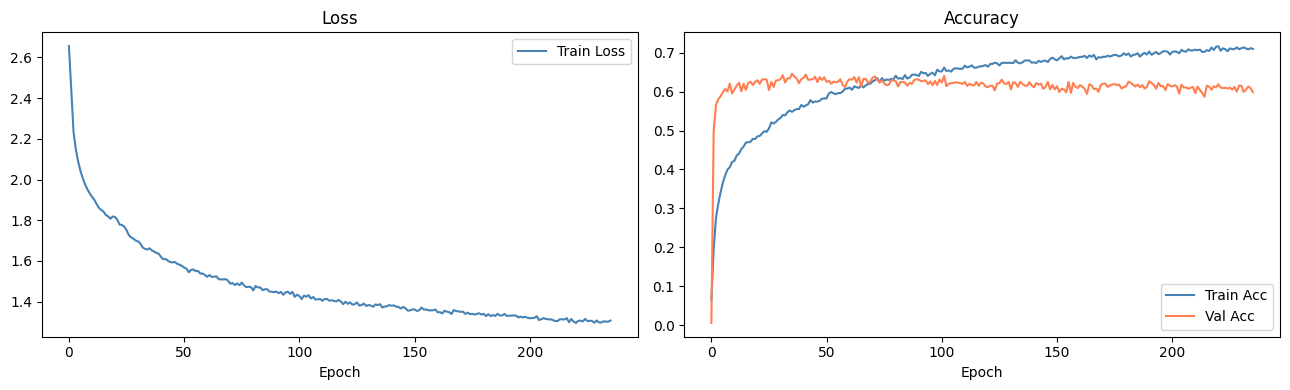


=== Meilleure val accuracy : 0.6456 ===


In [36]:
# Courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Acc', color='steelblue')
axes[1].plot(history['val_acc'],   label='Val Acc',   color='coral')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n=== Meilleure val accuracy : {max(history['val_acc']):.4f} ===")

In [37]:
# Rapport de classification complet
head.eval()
val_preds, val_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        preds = head(xb.to(DEVICE)).argmax(1).cpu().numpy()
        val_preds.extend(preds)
        val_true.extend(yb.numpy())

print(classification_report(
    val_true, val_preds,
    target_names=[str(c) for c in le.classes_]
))

              precision    recall  f1-score   support

          15       0.63      0.50      0.56       124
          16       0.87      0.95      0.91       270
          42       0.54      0.38      0.45       382
          52       0.00      0.00      0.00        63
          53       0.00      0.00      0.00         7
           6       0.24      0.23      0.23        35
          62       0.18      0.08      0.12       153
          64       0.00      0.00      0.00        24
          65       0.78      0.84      0.81       313
          67       0.08      0.01      0.03        68
          88       0.92      0.81      0.86       121
          90       0.60      0.88      0.71       777
          92       0.77      0.70      0.73        77
          95       0.41      0.17      0.24        52

    accuracy                           0.65      2466
   macro avg       0.43      0.40      0.40      2466
weighted avg       0.59      0.65      0.60      2466



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

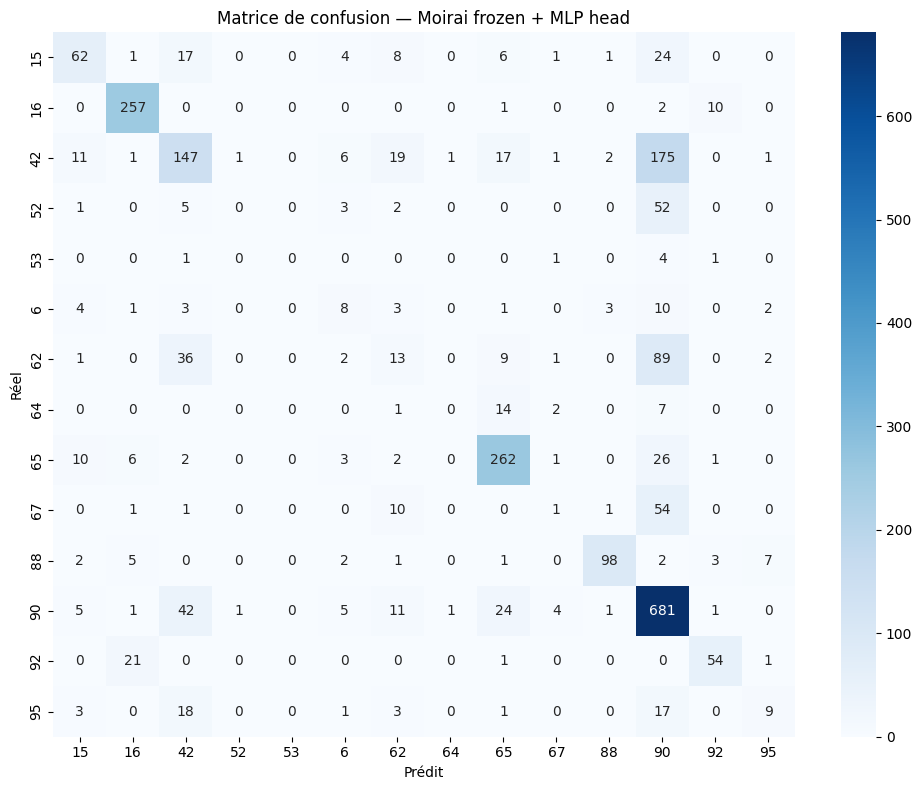

In [38]:
# Matrice de confusion
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(val_true, val_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_title('Matrice de confusion — Moirai frozen + MLP head')
plt.tight_layout()
plt.show()

## 9. Sauvegarde du modèle

In [35]:
torch.save({
    'head_state_dict': head.state_dict(),
    'label_encoder': le,
    'embed_dim': EMBED_DIM,
    'num_classes': NUM_CLASSES,
    'history': history,
}, 'moirai_lsst_head.pt')
print("Modèle sauvegardé : moirai_lsst_head.pt")

Modèle sauvegardé : moirai_lsst_head.pt


---
## Notes pour la suite

### Passer sur Colab GPU
- Changer `MODEL_SIZE = 'small'` → `'base'` ou `'large'`
- Augmenter `EPOCHS` à 100+
- Tester avec `BATCH_SIZE = 128`

### Améliorations possibles
- **Pooling alternatif** : CLS token, max-pooling, attention pooling
- **Stratégie multivarié** : mean-pooling des canaux au lieu de concaténation
- **Data augmentation** : jittering, scaling, time warping sur les séries
- **Fine-tuning partiel** : dégeler les dernières couches de Moirai (layer unfreezing progressif)

### Baseline à comparer (pour vos coéquipiers)
- **ROCKET** : très efficace sur LSST sans pré-entraînement
- **InceptionTime** : ResNet adapté aux séries temporelles
- **MLP simple** sur les séries brutes